# **PONTIFICIA UNIVERSIDAD JAVERIANA**
## **Procesamiento de alto volumen de datos**
**Fecha:** 7 de Abril del 2026

**Autor:** Grupo Sigma

**Tema:** Proyecto de Big Data

**Objetivo:** 
- Entender la importancia del uso de herramientas de Big Data en entornos empresariales, a fin de poder solucionar preguntas de negocio.
- Entender el paso a paso de un proyecto de procesamiento de datos para la generación de hallazgos de valor basado en la metodología CRISP-DM.
- Documentar la implementación de un cluster como infraestructura de procesamiento de grandes volúmenes de datos, a través de máquinas virtuales.
- Realizar procesamiento de datos aplicado a los resultados de las pruebas Saber 11 del ICFES a nivel nacional.

**Dataset:** Resultados_únicos_Saber_11_20260408.csv  
**Fuente:** Instituto Colombiano para la Evaluación de la Educación (ICFES) — Datos Abiertos  
**Registros:** ~7.11 millones de filas | 51 columnas  

**Version:** Entrega 1

Para asegurar que el proyecto funcione correctamente con pandas, matplotlib, seaborn y findspark, ejecutar el siguiente comando desde la raíz del proyecto
```bash
pip install -r requirements.txt
```

In [1]:
### Importación de bibliotecas basicas 
import os                       # -> Para gestion de archivos y procesos
import sys                      # -> Para manejo de recursos del sistema
import pandas as pd             # -> Para graficar y objetos dataframe
import numpy as np              # -> Para algebra matricial
import matplotlib.pyplot as plt # -> Para formatos de graficas
import seaborn as sns           # -> Para estadistica y graficar
import scipy.stats as stats     # -> Para pruebas estadisticas

In [2]:
### Importacion de bibliotecas especializadas
import findspark                                # -> Para manejo del entorno de PySpark
findspark.init('/Almacen/Spark')                # -> Se inicia el entorno para PySpark
from pyspark import SparkConf, SparkContext     # -> Para contexto y configuración de PySpark
from pyspark.sql import SparkSession            # -> Para manejo de Sesion en entorno de consultas SQL
from pyspark.sql.functions import *             # -> Para funciones de manipulacion de columnas
from pyspark.sql.types import IntegerType, StringType, DoubleType # -> Para definir tipos de datos
import pyspark.sql.functions as F               # -> Para funciones de manipulacion de columnas (alias)
from pyspark.ml.feature import VectorAssembler  # -> Para construcción de vectores  
from pyspark.ml.stat import Correlation         # -> Para calculo de correlaciones

In [3]:
configura = SparkConf()
configura.set('spark.scheduler.mode', 'FAIR')
configura.set('spark.scheduler.allocation', '/Almacen/Spark/conf/fairscheduler.xml')
configura.setMaster('spark://10.43.97.166:7077')
configura.setAppName('SigmaSPARK_ICFES')

sparkSigma = SparkSession.builder.config(conf=configura).getOrCreate()
sparkSigma

## **Lectura de data**

In [4]:
# Lectura del archivo CSV 

dfPy00 = sparkSigma.read.format("csv").option("header","true").load("../data/Resultados_únicos_Saber_11_20260408.csv")
dfPy00.show(5)

+-------+------------------+----------------+-------------------+-------------+---------------+-----------------+-----------------------------+------------------+------------------------+------------------------+-----------------+--------------------+-----------+------------+--------------------+---------------+---------------------------+----------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+--------------------+-----------+-----------------------+-----------------+-----------------+----------------+---------------------+-----------------+--------------------+--------------------+--------------------+------------------+-------------------+--------------------+------------------+------------------+-------------+-----------+----------------+------------------------+----------------+--------------------+-----------+
|PERIODO|

### 1 - Descripción general del dataset

El dataset corresponde a los **Resultados únicos de las pruebas Saber 11** publicados por el **ICFES (Instituto Colombiano para la Evaluación de la Educación)**. Contiene información sobre el desempeño académico de estudiantes de grado 11 en Colombia, junto con variables socioeconómicas y de contexto familiar.

**Principales grupos de variables:**
- **Identificación y período:** Año, periodo, número de documento del estudiante.
- **Ubicación geográfica:** Departamento y municipio del colegio y de residencia.
- **Contexto socioeconómico:** Estrato, nivel educativo de los padres, acceso a internet, computador en casa, número de personas en el hogar.
- **Información del colegio:** Nombre, naturaleza (oficial/privado), calendario, área (urbano/rural).
- **Puntajes por área:** Lectura crítica, matemáticas, ciencias naturales, sociales y ciudadanas, inglés.
- **Puntaje global:** Suma ponderada de las áreas evaluadas.

In [5]:
## Se listan los nombres de las columnas actuales y los nombres por los que deseo cambiar del dataframe
NombresOriginales = [
    'ESTU_TIPODOCUMENTO', 'ESTU_CONSECUTIVO', 'ESTU_GENERO', 'ESTU_FECHANACIMIENTO',
    'ESTU_PAIS_RESIDE', 'COLE_DEPTO_UBICACION', 'COLE_MPIO_UBICACION', 'COLE_AREA_UBICACION',
    'COLE_JORNADA', 'COLE_NATURALEZA', 'COLE_CALENDARIO', 'COLE_NOMBRE_ESTABLECIMIENTO',
    'FAMI_ESTRATOVIVIENDA', 'FAMI_TIENEINTERNET', 'FAMI_TIENECOMPUTADOR', 'FAMI_EDUCACIONPADRE',
    'FAMI_EDUCACIONMADRE', 'FAMI_NUMLIBROS', 'FAMI_CUARTOSHOGAR', 'FAMI_PERSONASHOGAR',
    'PERIODO', 'PUNT_LECTURA_CRITICA', 'PUNT_MATEMATICAS', 'PUNT_C_NATURALES',
    'PUNT_SOCIALES_CIUDADANAS', 'PUNT_INGLES', 'PUNT_GLOBAL'
]

NombresNuevos = [
    'TIPO_DOC', 'ID_ESTUDIANTE', 'GENERO', 'FECHA_NAC',
    'PAIS', 'DEPTO_COLEGIO', 'MUN_COLEGIO', 'AREA_COLEGIO',
    'JORNADA', 'NATURALEZA', 'CALENDARIO', 'NOMBRE_COLEGIO',
    'ESTRATO', 'TIENE_INTERNET', 'TIENE_COMPUTADOR', 'EDU_PADRE',
    'EDU_MADRE', 'NUM_LIBROS', 'CUARTOS_HOGAR', 'PERSONAS_HOGAR',
    'PERIODO', 'PUNT_LECTURA', 'PUNT_MATE', 'PUNT_CIENCIAS',
    'PUNT_SOCIALES', 'PUNT_INGLES', 'PUNT_GLOBAL'
]

#### Version
### original --> "Cambio de nombres de cada columna"
dfPy01 = dfPy00
for antes, nuevo in zip(NombresOriginales, NombresNuevos):
    if antes in dfPy01.columns:
        dfPy01 = dfPy01.withColumnRenamed(antes, nuevo)

dfPy01.columns

['PERIODO',
 'TIPO_DOC',
 'ID_ESTUDIANTE',
 'AREA_COLEGIO',
 'COLE_BILINGUE',
 'CALENDARIO',
 'COLE_CARACTER',
 'COLE_COD_DANE_ESTABLECIMIENTO',
 'COLE_COD_DANE_SEDE',
 'COLE_COD_DEPTO_UBICACION',
 'COLE_COD_MCPIO_UBICACION',
 'COLE_CODIGO_ICFES',
 'DEPTO_COLEGIO',
 'COLE_GENERO',
 'JORNADA',
 'COLE_MCPIO_UBICACION',
 'NATURALEZA',
 'NOMBRE_COLEGIO',
 'COLE_NOMBRE_SEDE',
 'COLE_SEDE_PRINCIPAL',
 'ESTU_COD_DEPTO_PRESENTACION',
 'ESTU_COD_MCPIO_PRESENTACION',
 'ESTU_COD_RESIDE_DEPTO',
 'ESTU_COD_RESIDE_MCPIO',
 'ESTU_DEPTO_PRESENTACION',
 'ESTU_DEPTO_RESIDE',
 'ESTU_ESTADOINVESTIGACION',
 'ESTU_ESTUDIANTE',
 'FECHA_NAC',
 'GENERO',
 'ESTU_MCPIO_PRESENTACION',
 'ESTU_MCPIO_RESIDE',
 'ESTU_NACIONALIDAD',
 'PAIS',
 'ESTU_PRIVADO_LIBERTAD',
 'CUARTOS_HOGAR',
 'EDU_MADRE',
 'EDU_PADRE',
 'ESTRATO',
 'PERSONAS_HOGAR',
 'FAMI_TIENEAUTOMOVIL',
 'TIENE_COMPUTADOR',
 'TIENE_INTERNET',
 'FAMI_TIENELAVADORA',
 'DESEMP_INGLES',
 'PUNT_INGLES',
 'PUNT_MATE',
 'PUNT_SOCIALES',
 'PUNT_CIENCIAS',
 'PUNT_

### 2 - Tipos y coherencia de datos

In [6]:
dfPy01.printSchema()

root
 |-- PERIODO: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- ID_ESTUDIANTE: string (nullable = true)
 |-- AREA_COLEGIO: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_COD_DANE_SEDE: string (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_CODIGO_ICFES: string (nullable = true)
 |-- DEPTO_COLEGIO: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- NATURALEZA: string (nullable = true)
 |-- NOMBRE_COLEGIO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: string (nullable = true)
 |-- ESTU_COD_DEPTO_PRESENTACION: string (nullable = true

In [7]:
import pyspark.sql.functions as F

# Inicializamos el dataframe de transformación
dfPy02 = dfPy01

# 1. Tratamiento de Variables Numéricas (Casting)
# ESTRATO viene como texto 'Estrato 1', 'Estrato 2', ... -> se extrae el número con regexp
dfPy02 = dfPy02.withColumn('ESTRATO',
    F.regexp_extract(F.col('ESTRATO'), r'(\d+)', 1).cast('int')
)

columnas_a_entero = ['PERSONAS_HOGAR', 'CUARTOS_HOGAR',
                     'PUNT_LECTURA', 'PUNT_MATE', 'PUNT_CIENCIAS',
                     'PUNT_SOCIALES', 'PUNT_INGLES', 'PUNT_GLOBAL']
for col_name in columnas_a_entero:
    if col_name in dfPy02.columns:
        dfPy02 = dfPy02.withColumn(col_name, F.col(col_name).cast('int'))

# 2. Estandarización de texto (Mayúsculas y quitar espacios en blanco)
columnas_texto = ['GENERO', 'AREA_COLEGIO', 'NATURALEZA', 'JORNADA',
                  'CALENDARIO', 'DEPTO_COLEGIO', 'MUN_COLEGIO',
                  'TIENE_INTERNET', 'TIENE_COMPUTADOR', 'EDU_PADRE', 'EDU_MADRE']
for c in columnas_texto:
    if c in dfPy02.columns:
        dfPy02 = dfPy02.withColumn(c, F.upper(F.trim(F.col(c))))

dfPy02.printSchema()

root
 |-- PERIODO: string (nullable = true)
 |-- TIPO_DOC: string (nullable = true)
 |-- ID_ESTUDIANTE: string (nullable = true)
 |-- AREA_COLEGIO: string (nullable = true)
 |-- COLE_BILINGUE: string (nullable = true)
 |-- CALENDARIO: string (nullable = true)
 |-- COLE_CARACTER: string (nullable = true)
 |-- COLE_COD_DANE_ESTABLECIMIENTO: string (nullable = true)
 |-- COLE_COD_DANE_SEDE: string (nullable = true)
 |-- COLE_COD_DEPTO_UBICACION: string (nullable = true)
 |-- COLE_COD_MCPIO_UBICACION: string (nullable = true)
 |-- COLE_CODIGO_ICFES: string (nullable = true)
 |-- DEPTO_COLEGIO: string (nullable = true)
 |-- COLE_GENERO: string (nullable = true)
 |-- JORNADA: string (nullable = true)
 |-- COLE_MCPIO_UBICACION: string (nullable = true)
 |-- NATURALEZA: string (nullable = true)
 |-- NOMBRE_COLEGIO: string (nullable = true)
 |-- COLE_NOMBRE_SEDE: string (nullable = true)
 |-- COLE_SEDE_PRINCIPAL: string (nullable = true)
 |-- ESTU_COD_DEPTO_PRESENTACION: string (nullable = true

In [8]:
# Análisis de Frecuencias para Variables Categóricas

# 1. Distribución por Género
print('Distribución por GÉNERO:')
dfPy02.groupby(['GENERO']).count().show()

# 2. Distribución por Área del colegio
print('Distribución por ÁREA DEL COLEGIO:')
dfPy02.groupby(['AREA_COLEGIO']).count().show()

# 3. Distribución por Naturaleza del colegio
print('Distribución por NATURALEZA DEL COLEGIO:')
dfPy02.groupby(['NATURALEZA']).count().show()

# 4. Distribución por Jornada
print('Distribución por JORNADA:')
dfPy02.groupby(['JORNADA']).count().show()

# 5. Distribución por Estrato
print('Distribución por ESTRATO:')
dfPy02.groupby(['ESTRATO']).count().orderBy('ESTRATO').show()

# 6. Distribución por Acceso a Internet
print('Distribución por TIENE_INTERNET:')
dfPy02.groupby(['TIENE_INTERNET']).count().show()

# Validación de Integridad de la Carga
print('-' * 30)
print('TOTAL DE REGISTROS:', dfPy02.count())
print('TOTAL REGISTROS ÚNICOS (DISTINCT):', dfPy02.distinct().count())
print('-' * 30)

# Verificación de nulos en llave primaria
print('REGISTROS SIN ID_ESTUDIANTE (NULOS):')
print(dfPy02.filter(F.col('ID_ESTUDIANTE').isNull()).count())

Distribución por GÉNERO:
+------+-------+
|GENERO|  count|
+------+-------+
|     F|3880677|
|  NULL|   3406|
|     M|3225621|
+------+-------+

Distribución por ÁREA DEL COLEGIO:
+------------+-------+
|AREA_COLEGIO|  count|
+------------+-------+
|        NULL|   3031|
|       RURAL|1000710|
|      URBANO|6105963|
+------------+-------+

Distribución por NATURALEZA DEL COLEGIO:
+----------+-------+
|NATURALEZA|  count|
+----------+-------+
|      NULL|     23|
|   OFICIAL|5134719|
|NO OFICIAL|1974962|
+----------+-------+

Distribución por JORNADA:
+--------+-------+
| JORNADA|  count|
+--------+-------+
|   UNICA| 464190|
|  MAÑANA|3413717|
|    NULL|     23|
|SABATINA| 454343|
|   TARDE| 964261|
|COMPLETA|1346879|
|   NOCHE| 466291|
+--------+-------+

Distribución por ESTRATO:
+-------+-------+
|ESTRATO|  count|
+-------+-------+
|   NULL| 307552|
|      1|2488247|
|      2|2441528|
|      3|1348516|
|      4| 323398|
|      5| 125691|
|      6|  74772|
+-------+-------+

Distribu

In [9]:
# Función para validar si es numérico y decidir si usar isnan
def count_missings(df):
    output = []
    for c, dtype in df.dtypes:
        # Si la columna es Double o Float, evaluar isNull e isnan
        if dtype in ['double', 'float']:
            output.append(F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c))
        # Para el resto, solo isNull
        else:
            output.append(F.count(F.when(F.col(c).isNull(), c)).alias(c))
    return output

# Ejecutar el select con la lógica filtrada
dfPy02.select(count_missings(dfPy02)).show()

+-------+--------+-------------+------------+-------------+----------+-------------+-----------------------------+------------------+------------------------+------------------------+-----------------+-------------+-----------+-------+--------------------+----------+--------------+----------------+-------------------+---------------------------+---------------------------+---------------------+---------------------+-----------------------+-----------------+------------------------+---------------+---------+------+-----------------------+-----------------+-----------------+----+---------------------+-------------+---------+---------+-------+--------------+-------------------+----------------+--------------+------------------+-------------+-----------+---------+-------------+-------------+------------+-----------+
|PERIODO|TIPO_DOC|ID_ESTUDIANTE|AREA_COLEGIO|COLE_BILINGUE|CALENDARIO|COLE_CARACTER|COLE_COD_DANE_ESTABLECIMIENTO|COLE_COD_DANE_SEDE|COLE_COD_DEPTO_UBICACION|COLE_COD_MCPIO_UBI

In [10]:
# Cálculo de porcentajes de nulos
import pyspark.sql.functions as F

total_registros = dfPy02.count()

print(f'Cantidad total de registros: {total_registros}')

columnas_a_revisar = [
    'GENERO', 'ESTRATO', 'PUNT_GLOBAL', 'PUNT_MATE',
    'PUNT_LECTURA', 'PUNT_CIENCIAS', 'PUNT_SOCIALES', 'PUNT_INGLES',
    'EDU_PADRE', 'EDU_MADRE', 'TIENE_INTERNET', 'TIENE_COMPUTADOR'
]

for col_name in columnas_a_revisar:
    if col_name in dfPy02.columns:
        nulos = dfPy02.filter(F.col(col_name).isNull()).count()
        pct = nulos * 100 / total_registros
        print(f'Porcentaje registros nulos en {col_name}: {__builtins__.round(pct, 4)}%')

duplicados = total_registros - dfPy02.distinct().count()

print(f'\nCantidad de registros duplicados: {duplicados}')
print(f'Porcentaje registros duplicados: {__builtins__.round(duplicados * 100 / total_registros, 4)}%')

Cantidad total de registros: 7109704
Porcentaje registros nulos en GENERO: 0.0479%
Porcentaje registros nulos en ESTRATO: 4.3258%
Porcentaje registros nulos en PUNT_GLOBAL: 36.7037%
Porcentaje registros nulos en PUNT_MATE: 0.0001%
Porcentaje registros nulos en PUNT_LECTURA: 36.7037%
Porcentaje registros nulos en PUNT_CIENCIAS: 36.7037%
Porcentaje registros nulos en PUNT_SOCIALES: 36.7037%
Porcentaje registros nulos en PUNT_INGLES: 0.0589%
Porcentaje registros nulos en EDU_PADRE: 2.9878%
Porcentaje registros nulos en EDU_MADRE: 2.9935%
Porcentaje registros nulos en TIENE_INTERNET: 2.6952%
Porcentaje registros nulos en TIENE_COMPUTADOR: 2.1269%

Cantidad de registros duplicados: 1387111
Porcentaje registros duplicados: 19.5101%


### **Analisis de nulos**

Tras ejecutar el diagnóstico de frecuencias y conteo de vacíos, se observan los siguientes hallazgos:
- **Género:** Variable con cobertura casi completa. Los registros nulos representan una fracción mínima y serán eliminados para no afectar los análisis demográficos.
- **Puntajes (PUNT_*):** Las columnas de puntajes son las variables objetivo del análisis. Los valores nulos corresponden a presentaciones incompletas o inválidas, y serán excluidos del análisis de rendimiento.
- **Educación de padres (EDU_PADRE, EDU_MADRE):** Variables con porcentaje relevante de valores nulos o categoría `No sabe`. Son importantes para el análisis socioeconómico.
- **Estrato:** Presenta valores nulos y posibles inconsistencias en la codificación (valores fuera del rango 1-6). Se tratarán como categoría especial `SIN_DATO`.
- **Internet y Computador:** Variables binarias con posibles nulos, relevantes para medir la brecha de conectividad digital.
- **Duplicados:** Se detectarán registros duplicados para aplicar la función `.distinct()` antes del modelado.

### **Decisiones de Tratamiento**

- **Limpieza de duplicados:** Se aplicará `.distinct()` para conservar una única presentación por estudiante por período.
- **Puntajes nulos:** Se eliminarán los registros donde `PUNT_GLOBAL` sea nulo, ya que representan presentaciones incompletas o inválidas.
- **Género nulo:** Se eliminarán los 105 registros con género NULL dada su irrelevancia estadística.
- **Estrato:** Los valores fuera del rango 1-6 se reclasificarán como `SIN_DATO` para no distorsionar el análisis socioeconómico.
- **Consolidación de Categorías (Educación de padres):** Se implementará un mapeo para unificar las categorías similares en etiquetas estándar.
- **Exclusión de Variables Incompletas:** Las columnas `PAIS` y `FECHA_NAC` serán descartadas de los análisis predictivos por su bajo aporte informativo.

## **Exploración de los datos**

In [11]:
# Estadísticas descriptivas para las variables numéricas principales
dfPy02.select(
    'ESTRATO', 'PUNT_LECTURA', 'PUNT_MATE', 'PUNT_CIENCIAS',
    'PUNT_SOCIALES', 'PUNT_INGLES', 'PUNT_GLOBAL'
).summary().show()

+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|summary|           ESTRATO|      PUNT_LECTURA|         PUNT_MATE|     PUNT_CIENCIAS|     PUNT_SOCIALES|       PUNT_INGLES|       PUNT_GLOBAL|
+-------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|  count|           6802152|           4500181|           7109697|           4500181|           4500181|           7105518|           4500181|
|   mean| 2.026936475397786| 52.18493945021322| 49.26133349986645|50.106060178468375|48.865357860050516|  48.5413650348926|252.30331691103092|
| stddev|1.0467480262138757|10.385771971965873|11.904398229288253|10.569585208236283| 11.73055591533721|12.222449561920369|50.426683241030624|
|    min|                 1|                 0|                 0|                 0|                 0|                -1|                 0|

A continuación se realiza una exploración visual de las principales variables numéricas del dataset para identificar su distribución, presencia de valores atípicos y posibles transformaciones necesarias.

In [12]:
# Conversión a Pandas para visualización
pdf = dfPy02.select(
    'ESTRATO', 'PUNT_LECTURA', 'PUNT_MATE', 'PUNT_CIENCIAS',
    'PUNT_SOCIALES', 'PUNT_INGLES', 'PUNT_GLOBAL',
    'GENERO', 'AREA_COLEGIO', 'NATURALEZA', 'TIENE_INTERNET'
).dropna(subset=['PUNT_GLOBAL']).toPandas()

print(f'Registros para visualización: {len(pdf)}')

Registros para visualización: 4500181


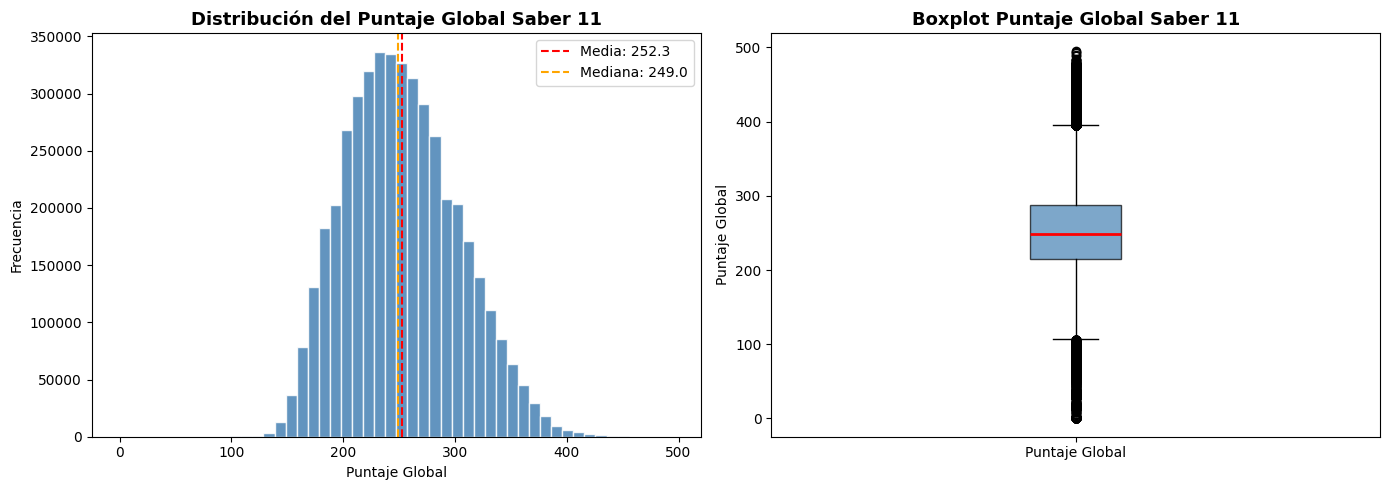

In [13]:
# Distribución del Puntaje Global
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(pdf['PUNT_GLOBAL'].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribución del Puntaje Global Saber 11', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(pdf['PUNT_GLOBAL'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Media: {pdf["PUNT_GLOBAL"].mean():.1f}')
axes[0].axvline(pdf['PUNT_GLOBAL'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Mediana: {pdf["PUNT_GLOBAL"].median():.1f}')
axes[0].legend()

# Boxplot
axes[1].boxplot(pdf['PUNT_GLOBAL'].dropna(), patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Boxplot Puntaje Global Saber 11', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Puntaje Global')
axes[1].set_xticks([1])
axes[1].set_xticklabels(['Puntaje Global'])

plt.tight_layout()
plt.show()

El histograma del Puntaje Global muestra una distribución aproximadamente normal con leve asimetría hacia la derecha. La mayoría de los estudiantes se concentra en el rango medio, con la media y la mediana cercanas entre sí. El boxplot permite identificar la presencia de valores atípicos tanto en el extremo inferior como en el superior, correspondientes a presentaciones de alto o bajo rendimiento.

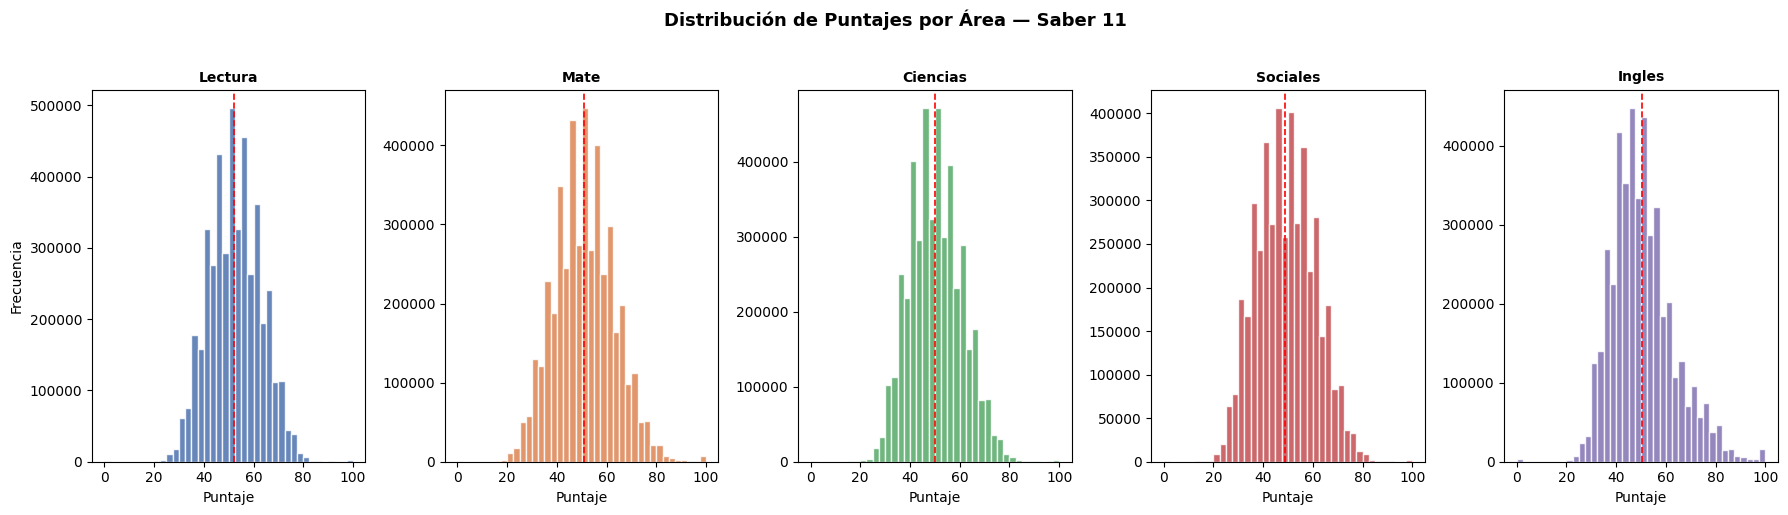

In [14]:
# Gráfico 2: Distribución de puntajes por área
puntajes_cols = ['PUNT_LECTURA', 'PUNT_MATE', 'PUNT_CIENCIAS', 'PUNT_SOCIALES', 'PUNT_INGLES']
colores = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, (col, color) in enumerate(zip(puntajes_cols, colores)):
    data = pdf[col].dropna()
    axes[i].hist(data, bins=40, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(col.replace('PUNT_', '').replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Puntaje')
    axes[i].set_ylabel('Frecuencia' if i == 0 else '')
    axes[i].axvline(data.mean(), color='red', linestyle='--', linewidth=1.2)

plt.suptitle('Distribución de Puntajes por Área — Saber 11', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Los puntajes por área presentan distribuciones unimodales con leve variabilidad entre áreas. Inglés tiende a mostrar mayor dispersión y asimetría, mientras que Lectura Crítica y Matemáticas presentan distribuciones más simétricas. La línea roja indica la media de cada área.

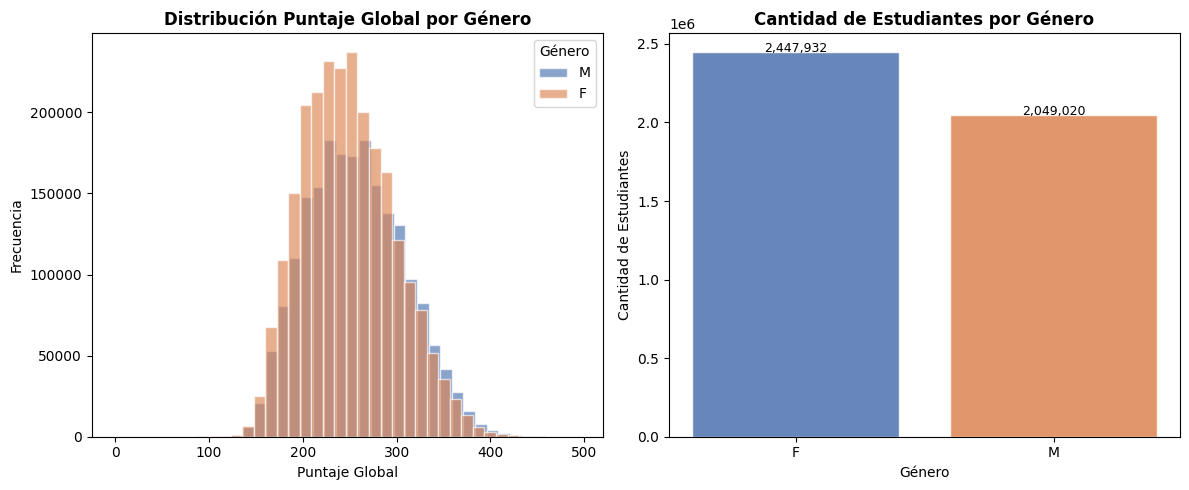

In [15]:
# Puntaje Global por Género
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

generos_validos = ['M', 'F']
pdf_genero = pdf[pdf['GENERO'].isin(generos_validos)]

for genero, color in zip(generos_validos, ['#4C72B0', '#DD8452']):
    data = pdf_genero[pdf_genero['GENERO'] == genero]['PUNT_GLOBAL'].dropna()
    axes[0].hist(data, bins=40, alpha=0.65, color=color, label=genero, edgecolor='white')

axes[0].set_title('Distribución Puntaje Global por Género', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Género')

conteo = pdf_genero['GENERO'].value_counts()
axes[1].bar(conteo.index, conteo.values, color=['#4C72B0', '#DD8452'], edgecolor='white', alpha=0.85)
axes[1].set_title('Cantidad de Estudiantes por Género', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Género')
axes[1].set_ylabel('Cantidad de Estudiantes')
for j, (idx, val) in enumerate(zip(conteo.index, conteo.values)):
    axes[1].text(j, val + 1000, f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

La distribución del puntaje global por género muestra diferencias sutiles entre estudiantes masculinos y femeninos. El dataset está relativamente balanceado en términos de participación por género. Cualquier diferencia en el rendimiento medio debe interpretarse en conjunto con variables de contexto como el tipo de colegio y el estrato.

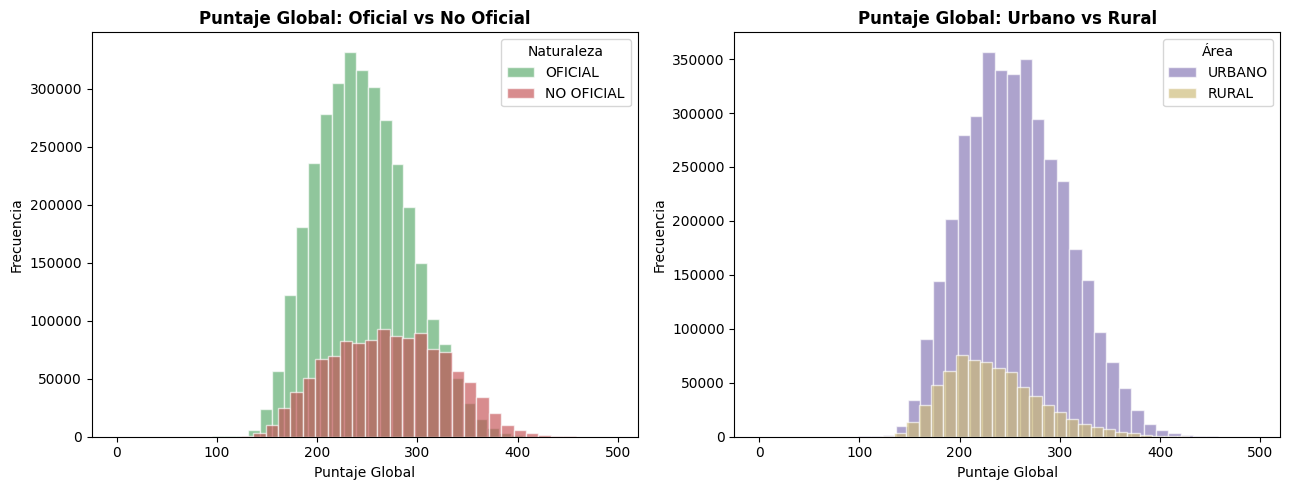

In [16]:
# Puntaje Global por Naturaleza del colegio y por Área
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Por naturaleza
for nat, color in zip(['OFICIAL', 'NO OFICIAL'], ['#55A868', '#C44E52']):
    data = pdf[pdf['NATURALEZA'] == nat]['PUNT_GLOBAL'].dropna()
    if len(data) > 0:
        axes[0].hist(data, bins=40, alpha=0.65, color=color, label=nat, edgecolor='white')
axes[0].set_title('Puntaje Global: Oficial vs No Oficial', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Puntaje Global')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(title='Naturaleza')

# Por área
for area, color in zip(['URBANO', 'RURAL'], ['#8172B2', '#CCB974']):
    data = pdf[pdf['AREA_COLEGIO'] == area]['PUNT_GLOBAL'].dropna()
    if len(data) > 0:
        axes[1].hist(data, bins=40, alpha=0.65, color=color, label=area, edgecolor='white')
axes[1].set_title('Puntaje Global: Urbano vs Rural', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Puntaje Global')
axes[1].set_ylabel('Frecuencia')
axes[1].legend(title='Área')

plt.tight_layout()
plt.show()

Los colegios no oficiales (privados) presentan una distribución del puntaje global desplazada hacia valores más altos en comparación con los colegios oficiales. De manera similar, los colegios urbanos tienden a superar a los rurales en rendimiento. Ambas variables reflejan desigualdades estructurales en el sistema educativo colombiano que serán objeto de análisis en fases posteriores del proyecto.

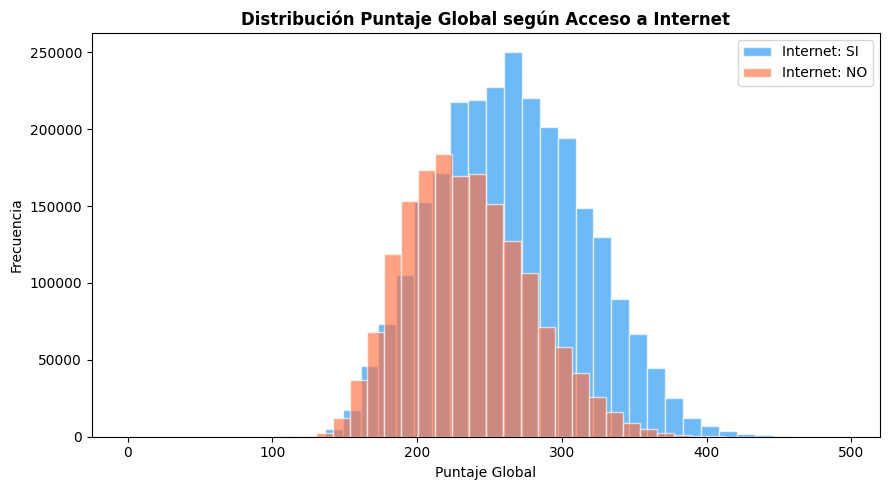

In [17]:
# Puntaje Global según acceso a Internet
fig, ax = plt.subplots(figsize=(9, 5))

for cat, color in zip(['SI', 'NO'], ['#2196F3', '#FF7043']):
    data = pdf[pdf['TIENE_INTERNET'] == cat]['PUNT_GLOBAL'].dropna()
    if len(data) > 0:
        ax.hist(data, bins=40, alpha=0.65, color=color, label=f'Internet: {cat}', edgecolor='white')

ax.set_title('Distribución Puntaje Global según Acceso a Internet', fontsize=12, fontweight='bold')
ax.set_xlabel('Puntaje Global')
ax.set_ylabel('Frecuencia')
ax.legend()

plt.tight_layout()
plt.show()

Los estudiantes con acceso a internet en el hogar presentan una distribución de puntaje global desplazada hacia valores más altos, sugiriendo una posible asociación entre conectividad y rendimiento académico. Esta variable actúa como un proxy de recursos del hogar y será incluida en los modelos explicativos.

## **Planteamiento de sub-preguntas investigativas**

1. ¿Existe una brecha significativa en el puntaje global Saber 11 entre colegios oficiales y no oficiales, y cómo varía esta brecha según el departamento?
2. ¿Qué tan fuerte es la relación entre el nivel educativo de los padres (EDU_PADRE, EDU_MADRE) y el rendimiento académico del estudiante en cada área evaluada?
3. ¿Qué variables socioeconómicas (estrato, acceso a internet, computador en casa, número de personas en el hogar) son los mejores predictores del puntaje global en las pruebas Saber 11?
4. ¿Existen diferencias estadísticamente significativas en el rendimiento por área (matemáticas, inglés, ciencias) entre colegios urbanos y rurales a nivel nacional?

## **Limpieza, filtro y transformaciones iniciales**

In [18]:
# Paso 1: Eliminación de duplicados
dfPy03 = dfPy02.distinct()
print('Registros tras eliminar duplicados:', dfPy03.count())

Registros tras eliminar duplicados: 5722593


In [19]:
# Paso 2: Eliminar registros sin PUNT_GLOBAL (presentaciones incompletas)
dfPy03 = dfPy03.filter(F.col('PUNT_GLOBAL').isNotNull())
print('Registros tras eliminar nulos en PUNT_GLOBAL:', dfPy03.count())

Registros tras eliminar nulos en PUNT_GLOBAL: 3395834


In [20]:
# Paso 3: Eliminar registros sin GENERO
dfPy03 = dfPy03.filter(F.col('GENERO').isNotNull())
print('Registros tras eliminar nulos en GENERO:', dfPy03.count())

Registros tras eliminar nulos en GENERO: 3392749


In [21]:
# Paso 4: Descarte de columnas con alta ausencia o bajo aporte informativo
columnas_a_descartar = ['PAIS', 'FECHA_NAC', 'TIPO_DOC']
dfPy03 = dfPy03.drop(*[c for c in columnas_a_descartar if c in dfPy03.columns])
print('Columnas restantes:', dfPy03.columns)

Columnas restantes: ['PERIODO', 'ID_ESTUDIANTE', 'AREA_COLEGIO', 'COLE_BILINGUE', 'CALENDARIO', 'COLE_CARACTER', 'COLE_COD_DANE_ESTABLECIMIENTO', 'COLE_COD_DANE_SEDE', 'COLE_COD_DEPTO_UBICACION', 'COLE_COD_MCPIO_UBICACION', 'COLE_CODIGO_ICFES', 'DEPTO_COLEGIO', 'COLE_GENERO', 'JORNADA', 'COLE_MCPIO_UBICACION', 'NATURALEZA', 'NOMBRE_COLEGIO', 'COLE_NOMBRE_SEDE', 'COLE_SEDE_PRINCIPAL', 'ESTU_COD_DEPTO_PRESENTACION', 'ESTU_COD_MCPIO_PRESENTACION', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_DEPTO_PRESENTACION', 'ESTU_DEPTO_RESIDE', 'ESTU_ESTADOINVESTIGACION', 'ESTU_ESTUDIANTE', 'GENERO', 'ESTU_MCPIO_PRESENTACION', 'ESTU_MCPIO_RESIDE', 'ESTU_NACIONALIDAD', 'ESTU_PRIVADO_LIBERTAD', 'CUARTOS_HOGAR', 'EDU_MADRE', 'EDU_PADRE', 'ESTRATO', 'PERSONAS_HOGAR', 'FAMI_TIENEAUTOMOVIL', 'TIENE_COMPUTADOR', 'TIENE_INTERNET', 'FAMI_TIENELAVADORA', 'DESEMP_INGLES', 'PUNT_INGLES', 'PUNT_MATE', 'PUNT_SOCIALES', 'PUNT_CIENCIAS', 'PUNT_LECTURA', 'PUNT_GLOBAL']


In [22]:
# Paso 5: Ver todos los valores en ESTRATO
dfPy03.groupby('ESTRATO').count().orderBy('count', ascending=False).show(20, truncate=False)

+-------+-------+
|ESTRATO|count  |
+-------+-------+
|1      |1209264|
|2      |1140572|
|3      |626700 |
|NULL   |159458 |
|4      |156743 |
|5      |61777  |
|6      |38235  |
+-------+-------+



In [23]:
# Reclasificación del Estrato — valores fuera del rango 1-6 marcados como SIN_DATO
dfPy03 = dfPy03.withColumn('ESTRATO',
    F.when(F.col('ESTRATO').between(1, 6), F.col('ESTRATO').cast('string'))
     .otherwise(F.lit('SIN_DATO'))
)

print('Categorías de ESTRATO tras reclasificación:')
dfPy03.groupby('ESTRATO').count().orderBy(F.col('count').desc()).show()

Categorías de ESTRATO tras reclasificación:
+--------+-------+
| ESTRATO|  count|
+--------+-------+
|       1|1209264|
|       2|1140572|
|       3| 626700|
|SIN_DATO| 159458|
|       4| 156743|
|       5|  61777|
|       6|  38235|
+--------+-------+



In [24]:
# Consolidación mejorada de categorías en Educación de Padres
def consolidar_educacion(col_name, df):
    return df.withColumn(col_name,
        F.when(F.col(col_name).rlike('(?i)ninguno|ninguna'), 'NINGUNO')
         .when(F.col(col_name).rlike('(?i)primaria'), 'PRIMARIA')
         .when(F.col(col_name).rlike('(?i)secundaria|bachillerato'), 'SECUNDARIA')
         .when(F.col(col_name).rlike('(?i)técnica|tecnológica|tecnologica'), 'TECNICA_TECNOLOGICA')
         .when(F.col(col_name).rlike('(?i)universitaria|profesional'), 'UNIVERSITARIA')
         .when(F.col(col_name).rlike('(?i)postgrado|posgrado|maestría|maestria|doctorado'), 'POSTGRADO')
         .when(F.col(col_name).isNull() | F.col(col_name).rlike('(?i)no sabe|sin info'), 'SIN_INFORMACION')
         .otherwise(F.col(col_name))
    )

if 'EDU_PADRE' in dfPy03.columns:
    dfPy03 = consolidar_educacion('EDU_PADRE', dfPy03)
if 'EDU_MADRE' in dfPy03.columns:
    dfPy03 = consolidar_educacion('EDU_MADRE', dfPy03)

print('Categorías de EDU_MADRE tras consolidación:')
dfPy03.groupby('EDU_MADRE').count().orderBy(F.col('count').desc()).show(truncate=False)

Categorías de EDU_MADRE tras consolidación:
+--------------------------------+-------+
|EDU_MADRE                       |count  |
+--------------------------------+-------+
|SECUNDARIA                      |1374591|
|PRIMARIA                        |918798 |
|UNIVERSITARIA                   |412419 |
|TÉCNICA O TECNOLÓGICA COMPLETA  |286118 |
|SIN_INFORMACION                 |154243 |
|TÉCNICA O TECNOLÓGICA INCOMPLETA|86276  |
|POSTGRADO                       |81633  |
|NINGUNO                         |75294  |
|NO APLICA                       |3377   |
+--------------------------------+-------+



In [ ]:
# Verificación final de nulos tras tratamiento
print('Conteo de nulos tras tratamiento:')
dfPy03.select(count_missings(dfPy03)).show()

print('Total de registros finales:', dfPy03.count())

Conteo de nulos tras tratamiento:


In [ ]:
# Conversión del dataframe limpio a Pandas para visualizaciones finales
pdf_final = dfPy03.select(
    'PUNT_GLOBAL', 'PUNT_MATE', 'PUNT_LECTURA', 'PUNT_INGLES',
    'PUNT_CIENCIAS', 'PUNT_SOCIALES'
).dropna().toPandas()

print(f'Registros para análisis final: {len(pdf_final)}')

Dado los resultados obtenidos en el análisis exploratorio, y con el fin de preparar los datos para posibles modelos con supuestos de normalidad, se considera la transformación de variables numéricas sesgadas como el PUNTAJE GLOBAL. Se conservarán también los datos base para técnicas sin supuestos de normalidad o para mayor explicabilidad de los modelos. La comparación entre la distribución original y la transformada logarítmicamente permite evaluar si la transformación mejora la simetría de los datos. Una distribución más simétrica tras la transformación facilitará la aplicación de modelos estadísticos con supuestos de normalidad en fases posteriores del proyecto.